,round,client_id,epoch,lossTrain,lossTest,lossTestGlobal
1,1,63521851-cdde-44aa-8dde-7124c7c11075,1,3.871375,3.383704,3.376386
0,1,6f27ee6a-40a0-4880-930f-5e609b471007,1,3.884705,3.363019,3.376253
2,1,fbb474de-14fb-4fa4-89f8-73f309588554,1,3.872182,3.343864,3.376342
4,2,63521851-cdde-44aa-8dde-7124c7c11075,2,3.439779,3.378604,3.370942
3,2,6f27ee6a-40a0-4880-930f-5e609b471007,2,3.452198,3.357463,3.370941


,round,client_id,task,trainLoss,testLoss,testLossGlobal,trainMetric,testMetric,testMetricGlobal
8,1,63521851-cdde-44aa-8dde-7124c7c11075,depth,0.046195,0.059807,0.052784,0.533613,0.503567,0.533202
6,1,63521851-cdde-44aa-8dde-7124c7c11075,edge,0.692906,0.692205,0.692191,0.225398,0.270708,0.217034
9,1,63521851-cdde-44aa-8dde-7124c7c11075,normal,0.332777,0.331886,0.331904,100.852646,61.527050,58.381851
7,1,63521851-cdde-44aa-8dde-7124c7c11075,saliency,0.692971,0.692622,0.692523,0.183918,0.000000,0.000000
5,1,63521851-cdde-44aa-8dde-7124c7c11075,semseg,1.608784,1.607184,1.606985,0.089757,0.152500,0.162742


,round,meanDeltaNorm,meanClientDeltaNorm,meanDistToMean,meanCosine,fracNegativeCosine
0,1,0.416984,0.722665,0.590227,-0.000591,0.333333
1,2,0.475242,0.583339,0.338274,0.495585,0.000000
2,3,0.516124,0.562088,0.222619,0.764708,0.000000
3,4,0.535580,0.561323,0.168039,0.865573,0.000000
4,5,0.545482,0.562418,0.136978,0.911024,0.000000


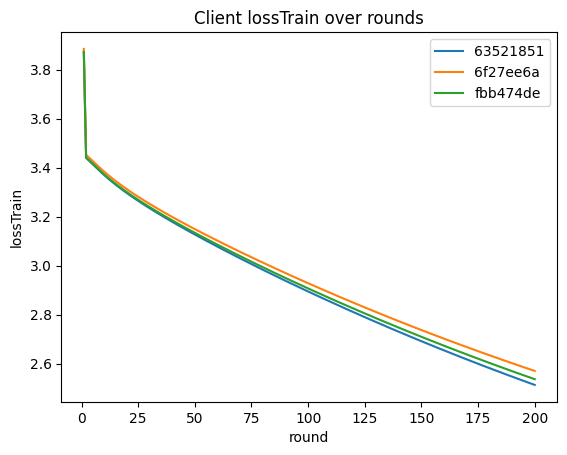

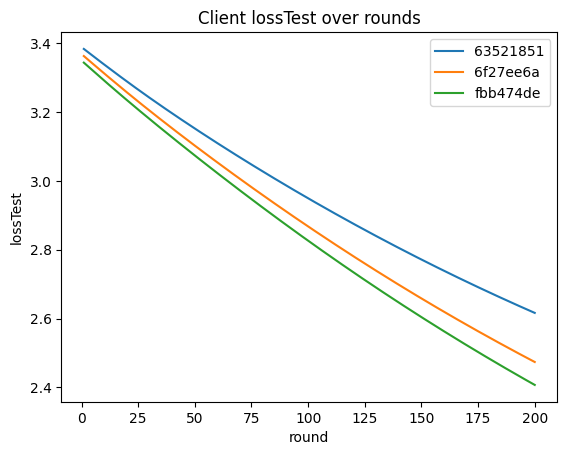

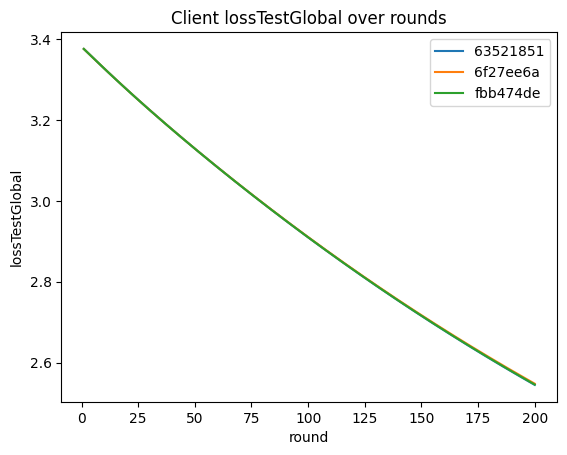

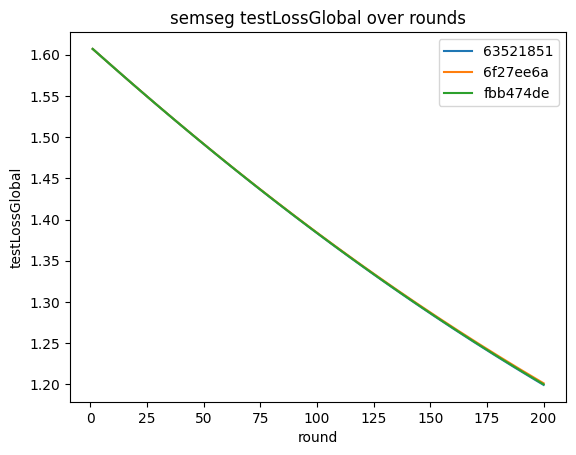

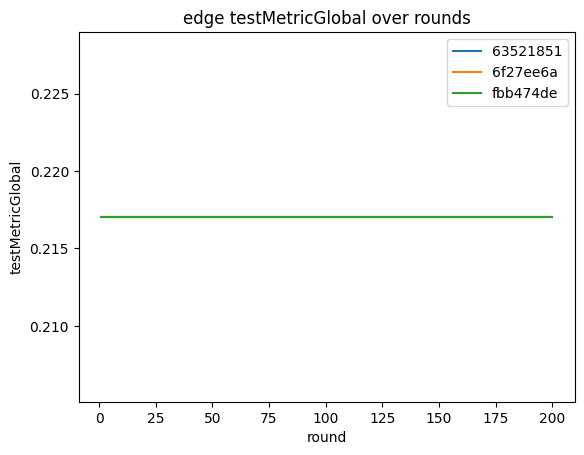

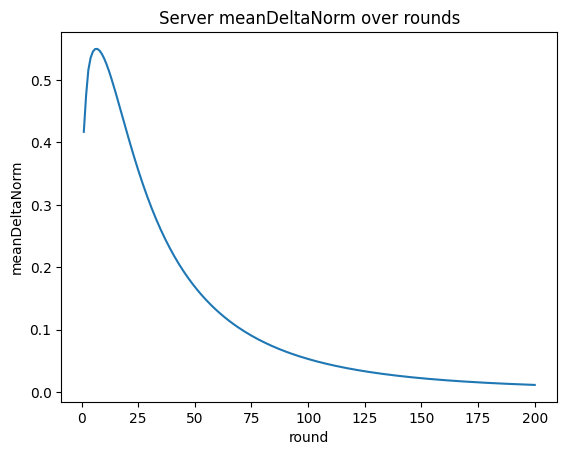

In [3]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# ---------- 1) Load ----------
# path = Path("../results/label_skew/low/label_skew_low_none.json") 
path = Path("../results/label_skew/low/label_skew_low_fedavg.json")
with path.open("r") as f:
    data = json.load(f)

# ---------- 2) Flatten: rounds -> clientMetrics (round-level per client) ----------
rows_client = []
for r in data.get("rounds", []):
    rnd = r.get("round")
    for cm in r.get("clientMetrics", []):
        rows_client.append({
            "round": rnd,
            "client_id": cm.get("id"),
            "epoch": cm.get("epoch"),
            "lossTrain": cm.get("lossTrain"),
            "lossTest": cm.get("lossTest"),
            "lossTestGlobal": cm.get("lossTestGlobal"),
        })

df_client_round = pd.DataFrame(rows_client).sort_values(["round", "client_id"])

# ---------- 3) Flatten: rounds -> clientMetrics -> perHead (task-level per client) ----------
rows_task = []
for r in data.get("rounds", []):
    rnd = r.get("round")
    for cm in r.get("clientMetrics", []):
        cid = cm.get("id")
        for head in cm.get("perHead", []):
            rows_task.append({
                "round": rnd,
                "client_id": cid,
                "task": head.get("task"),
                "trainLoss": head.get("trainLoss"),
                "testLoss": head.get("testLoss"),
                "testLossGlobal": head.get("testLossGlobal"),
                "trainMetric": head.get("trainMetric"),
                "testMetric": head.get("testMetric"),
                "testMetricGlobal": head.get("testMetricGlobal"),
            })

df_task_round = pd.DataFrame(rows_task).sort_values(["round", "client_id", "task"])

# ---------- 4) Flatten: rounds -> serverMetrics ----------
rows_server = []
for r in data.get("rounds", []):
    rnd = r.get("round")
    sm = r.get("serverMetrics") or {}
    rows_server.append({"round": rnd, **sm})

df_server_round = pd.DataFrame(rows_server).sort_values("round")

# ---------- 5) Peek ----------
display(df_client_round.head())
display(df_task_round.head())
display(df_server_round.head())

# ---------- 6) Plot helpers ----------
def plot_client_series(df, y, title):
    plt.figure()
    for cid, g in df.groupby("client_id"):
        plt.plot(g["round"], g[y], label=cid[:8])
    plt.xlabel("round")
    plt.ylabel(y)
    plt.title(title)
    plt.legend()
    plt.show()

def plot_task_series(df, task, y, title):
    plt.figure()
    sub = df[df["task"] == task]
    for cid, g in sub.groupby("client_id"):
        plt.plot(g["round"], g[y], label=cid[:8])
    plt.xlabel("round")
    plt.ylabel(y)
    plt.title(title)
    plt.legend()
    plt.show()

# ---------- 7) Example visualizations ----------
# Overall client losses
plot_client_series(df_client_round, "lossTrain", "Client lossTrain over rounds")
plot_client_series(df_client_round, "lossTest", "Client lossTest over rounds")
plot_client_series(df_client_round, "lossTestGlobal", "Client lossTestGlobal over rounds")

# Per-task curves (pick a task)
plot_task_series(df_task_round, "semseg", "testLossGlobal", "semseg testLossGlobal over rounds")
plot_task_series(df_task_round, "edge", "testMetricGlobal", "edge testMetricGlobal over rounds")

# Server metrics
plt.figure()
plt.plot(df_server_round["round"], df_server_round["meanDeltaNorm"])
plt.xlabel("round")
plt.ylabel("meanDeltaNorm")
plt.title("Server meanDeltaNorm over rounds")
plt.show()

In [13]:
import json
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------- CONFIG --------------------
ROOT = Path("../results/label_skew/low")  # adjust to your folder
FILES = {
    "none": "label_skew_low_none.json",
    "fedavg": "label_skew_low_fedavg.json",
    "fedhca2": "label_skew_low_fedhca2.json",
}

# If deltaM vectors are huge, comparisons can get slow.
# This truncates deltaM vectors (after deterministic flattening) for cosine/L2 comparisons.
DELTA_M_MAX_DIM = 20000  # set None to disable truncation

# Toggle which plot families you want
PLOT_OVERALL = True
PLOT_PERTASK = True
PLOT_SERVER = True
PLOT_DELTAM = True

# When plotting per-task, you may generate a lot of figures (tasks * metrics).
# You can limit tasks or metrics here:
TASK_WHITELIST = None  # e.g. ["semseg", "edge"] or None for all
PERTASK_COLUMNS = [
    # losses
    "trainLoss", "testLoss", "testLossGlobal",
    # metrics
    "trainMetric", "testMetric", "testMetricGlobal",
]


# -------------------- Helpers: deltaM flattening --------------------
def get_round_deltaM(round_obj):
    """
    deltaM might appear as:
      - round_obj["deltaM"]
      - round_obj["serverMetrics"]["deltaM"]
    We return it as-is if it's numeric; else None.
    """
    dm = None
    if isinstance(round_obj, dict):
        if round_obj.get("deltaM") is not None:
            dm = round_obj.get("deltaM")
        elif isinstance(round_obj.get("serverMetrics"), dict) and round_obj["serverMetrics"].get("deltaM") is not None:
            dm = round_obj["serverMetrics"].get("deltaM")

    # "plot directly" => assume scalar
    if isinstance(dm, (int, float)):
        return float(dm)
    return None


# -------------------- Parse one file into tidy frames --------------------
def parse_log(filepath, algo_name):
    with open(filepath, "r") as f:
        data = json.load(f)

    # rounds -> clientMetrics (overall)
    rows_client = []
    # rounds -> clientMetrics -> perHead (per-task)
    rows_task = []
    # rounds -> serverMetrics
    rows_server = []
    # rounds -> deltaM summary
    rows_delta = []

    for r in data.get("rounds", []):
        rnd = r.get("round")

        # --- server metrics
        sm = r.get("serverMetrics") or {}
        rows_server.append({"algo": algo_name, "round": rnd, **sm})

        # deltaM (scalar)
        rows_delta.append({
            "algo": algo_name,
            "round": rnd,
            "deltaM": get_round_deltaM(r)
        })

        # --- client metrics
        for cm in r.get("clientMetrics", []) or []:
            rows_client.append({
                "algo": algo_name,
                "round": rnd,
                "client_id": cm.get("id"),
                "epoch": cm.get("epoch"),
                "lossTrain": cm.get("lossTrain"),
                "lossTest": cm.get("lossTest"),
                "lossTestGlobal": cm.get("lossTestGlobal"),
            })

            # per task
            for head in cm.get("perHead", []) or []:
                rows_task.append({
                    "algo": algo_name,
                    "round": rnd,
                    "client_id": cm.get("id"),
                    "task": head.get("task"),
                    "trainLoss": head.get("trainLoss"),
                    "testLoss": head.get("testLoss"),
                    "testLossGlobal": head.get("testLossGlobal"),
                    "trainMetric": head.get("trainMetric"),
                    "testMetric": head.get("testMetric"),
                    "testMetricGlobal": head.get("testMetricGlobal"),
                })

    df_client = pd.DataFrame(rows_client).sort_values(["algo", "round", "client_id"])
    df_task = pd.DataFrame(rows_task).sort_values(["algo", "round", "client_id", "task"])
    df_server = pd.DataFrame(rows_server).sort_values(["algo", "round"])
    df_delta = pd.DataFrame(rows_delta).sort_values(["algo", "round"])

    # handy metadata
    header = data.get("header", {})
    server_cfg = (header.get("server") or {})
    df_meta = pd.DataFrame([{"algo": algo_name, **server_cfg}])

    return df_client, df_task, df_server, df_delta, df_meta


# -------------------- Load all logs --------------------
all_client, all_task, all_server, all_delta, all_meta = [], [], [], [], []

for algo, fp in FILES.items():
    p = Path(ROOT, fp)
    if not p.exists():
        raise FileNotFoundError(f"Missing file: {fp} (expected for algo='{algo}')")
    dc, dt, ds, dd, dm = parse_log(str(p), algo)
    all_client.append(dc)
    all_task.append(dt)
    all_server.append(ds)
    all_delta.append(dd)
    all_meta.append(dm)

df_client = pd.concat(all_client, ignore_index=True)
df_task = pd.concat(all_task, ignore_index=True)
df_server = pd.concat(all_server, ignore_index=True)
df_delta = pd.concat(all_delta, ignore_index=True)
df_meta = pd.concat(all_meta, ignore_index=True)

display(df_meta)
display(df_client.head())
display(df_task.head())
display(df_server.head())
display(df_delta.head())

C:\Users\ern yon\AppData\Local\Temp\ipykernel_42052\658417279.py:144: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_delta = pd.concat(all_delta, ignore_index=True)


,algo,epochsPerClient,encoderAgg,decoderAgg,caC,cac,rounds
0,none,1,none,none,0.0,0.0,200
1,fedavg,1,fedavg,fedavg,0.0,0.0,200
2,fedhca2,1,conflict_averse,cross_attention,0.5,0.5,200


,algo,round,client_id,epoch,lossTrain,lossTest,lossTestGlobal
0,none,1,568ace0a-e9da-4f9a-8da3-2140d518a8e2,1,3.872946,3.380968,3.376378
1,none,1,8ccb0f90-8b0f-439b-ae4d-4647f02b10f6,1,3.890604,3.373826,3.376300
2,none,1,9cc9df6a-c6e2-4143-a7e3-9c768faafd11,1,3.877028,3.357854,3.376415
3,none,2,568ace0a-e9da-4f9a-8da3-2140d518a8e2,2,3.850988,3.375371,3.370881
4,none,2,8ccb0f90-8b0f-439b-ae4d-4647f02b10f6,2,3.868991,3.368224,3.370784


,algo,round,client_id,task,trainLoss,testLoss,testLossGlobal,trainMetric,testMetric,testMetricGlobal
0,none,1,568ace0a-e9da-4f9a-8da3-2140d518a8e2,depth,0.047211,0.057187,0.052809,0.533826,0.571631,0.533327
1,none,1,568ace0a-e9da-4f9a-8da3-2140d518a8e2,edge,0.692910,0.692191,0.692192,0.200530,0.204769,0.217034
2,none,1,568ace0a-e9da-4f9a-8da3-2140d518a8e2,normal,0.332794,0.332180,0.331899,70.827255,51.104706,50.846844
3,none,1,568ace0a-e9da-4f9a-8da3-2140d518a8e2,saliency,0.692978,0.692501,0.692523,0.151693,0.000000,0.000000
4,none,1,568ace0a-e9da-4f9a-8da3-2140d518a8e2,semseg,1.608772,1.606909,1.606955,0.160177,0.205981,0.162742


,algo,round,meanDeltaNorm,meanClientDeltaNorm,meanDistToMean,meanCosine,fracNegativeCosine
0,none,1,0.418116,0.722777,0.589563,0.001968,0.333333
1,none,2,0.414730,0.716931,0.584799,0.001956,0.333333
2,none,3,0.410223,0.709228,0.578551,0.001832,0.333333
3,none,4,0.404992,0.700287,0.571299,0.001685,0.333333
4,none,5,0.399239,0.690416,0.563278,0.001573,0.333333


,algo,round,deltaM
0,none,1,NaN
1,none,2,NaN
2,none,3,NaN
3,none,4,NaN
4,none,5,NaN


In [6]:
def plot_algo_curves(df, y, title, group_cols=("algo", "round"), x="round", show_std=True):
    """
    Expects df with columns: algo, round, and y.
    Plots mean across whatever remains (e.g., clients) per (algo, round).
    """
    agg = df.groupby(list(group_cols))[y].agg(["mean", "std", "count"]).reset_index()
    plt.figure()
    for algo, g in agg.groupby("algo"):
        g = g.sort_values(x)
        plt.plot(g[x], g["mean"], label=algo)
        if show_std:
            # std may be NaN for count=1
            lo = g["mean"] - g["std"].fillna(0)
            hi = g["mean"] + g["std"].fillna(0)
            plt.fill_between(g[x], lo, hi, alpha=0.2)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(title)
    plt.legend()
    plt.show()


def plot_server_metric(metric):
    if metric not in df_server.columns:
        print(f"Skipping server metric (not found): {metric}")
        return
    plot_algo_curves(df_server, metric, f"Server: {metric} over rounds", group_cols=("algo", "round"), show_std=False)


def plot_overall_metric(metric):
    if metric not in df_client.columns:
        print(f"Skipping overall metric (not found): {metric}")
        return
    plot_algo_curves(df_client, metric, f"Overall (client): {metric} over rounds", group_cols=("algo", "round"), show_std=True)


def plot_task_metric(task, metric):
    sub = df_task[df_task["task"] == task]
    if sub.empty:
        print(f"Skipping task '{task}' (no rows).")
        return
    if metric not in sub.columns:
        print(f"Skipping task metric (not found): {metric}")
        return
    plot_algo_curves(sub, metric, f"Task='{task}': {metric} over rounds", group_cols=("algo", "round"), show_std=True)

In [14]:
def plot_algo_with_clients(df, y, title, filter_df=None, shade_minmax=True):
    """
    df must have columns: algo, round, client_id (optional), and y.
    - Plots each client's curve per algo (thin)
    - Overlays mean per algo (thicker)
    - Optionally shades min-max per algo (nice for 3 clients)
    """
    if filter_df is not None:
        df = filter_df(df)

    if y not in df.columns:
        print(f"Missing column: {y}")
        return

    plt.figure()

    # If client_id exists, draw thin per-client lines
    has_clients = "client_id" in df.columns

    for algo, g_algo in df.groupby("algo"):
        g_algo = g_algo.sort_values("round")

        if has_clients:
            for cid, g_c in g_algo.groupby("client_id"):
                plt.plot(g_c["round"], g_c[y], alpha=0.25)

        # mean/min/max across clients for each round
        agg = g_algo.groupby("round")[y].agg(["mean", "min", "max"]).reset_index().sort_values("round")
        plt.plot(agg["round"], agg["mean"], label=algo)

        if shade_minmax and has_clients:
            plt.fill_between(agg["round"], agg["min"], agg["max"], alpha=0.15)

    plt.xlabel("round")
    plt.ylabel(y)
    plt.title(title)
    plt.legend()
    plt.show()


def plot_algo_scalar(df, y, title):
    """
    For already-round-level scalars (no client_id), overlays algorithms directly.
    """
    if y not in df.columns:
        print(f"Missing column: {y}")
        return

    plt.figure()
    for algo, g in df.groupby("algo"):
        g = g.sort_values("round")
        plt.plot(g["round"], g[y], label=algo)
    plt.xlabel("round")
    plt.ylabel(y)
    plt.title(title)
    plt.legend()
    plt.show()

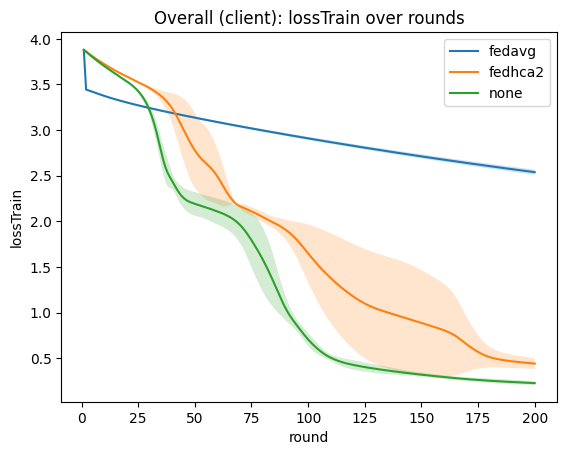

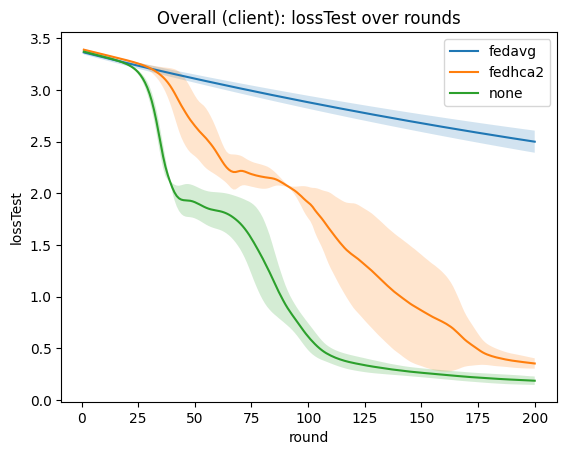

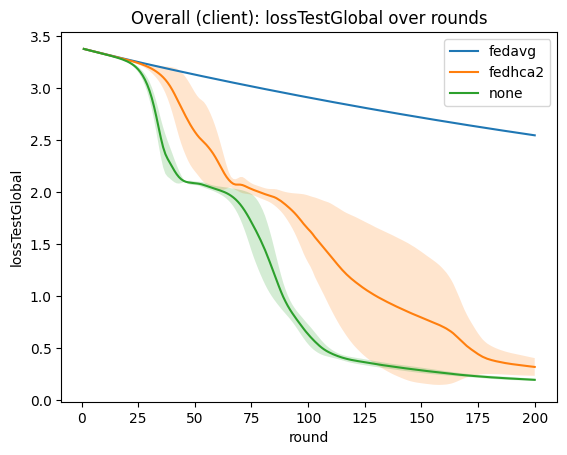

In [7]:
if PLOT_OVERALL:
    for col in ["lossTrain", "lossTest", "lossTestGlobal"]:
        plot_overall_metric(col)

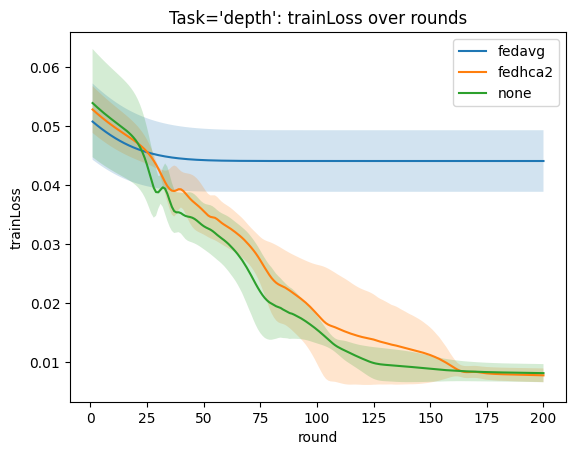

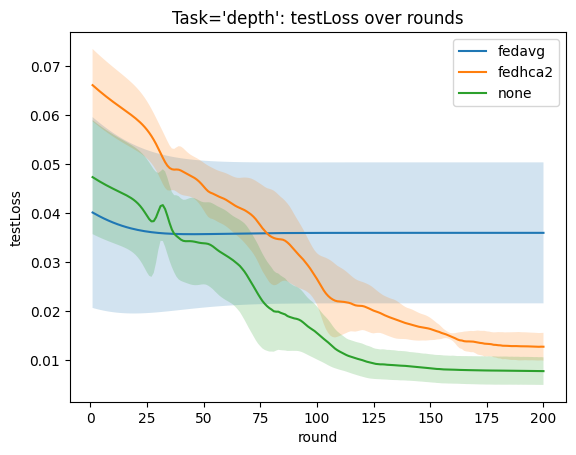

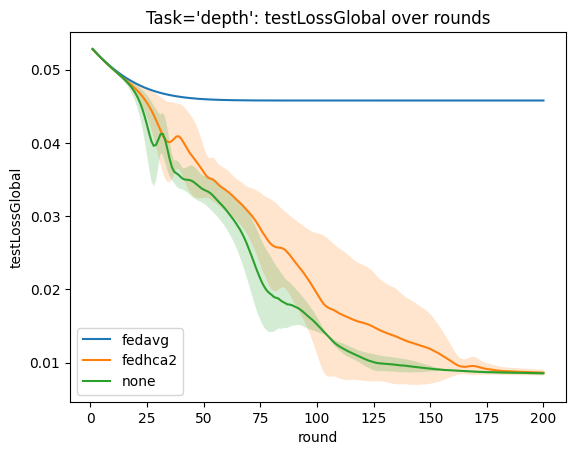

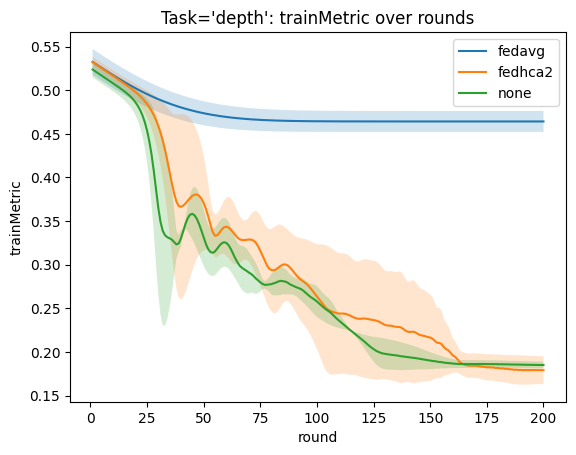

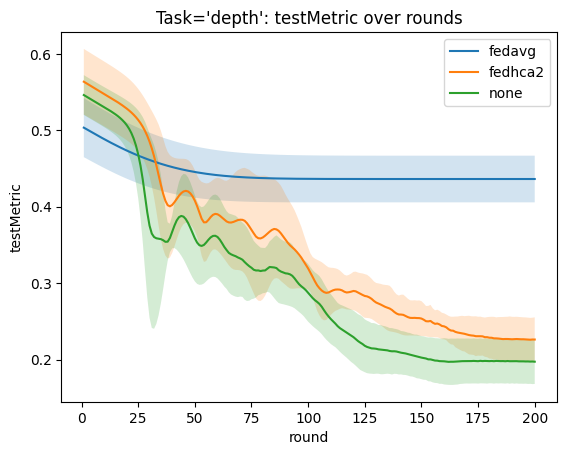

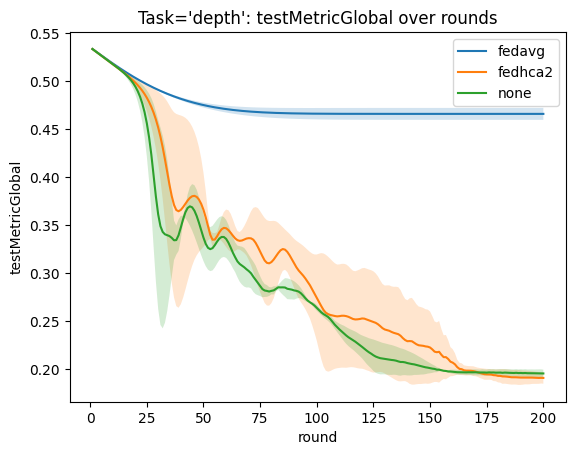

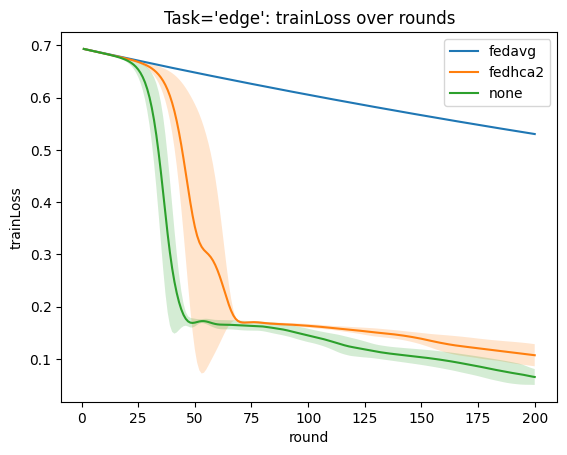

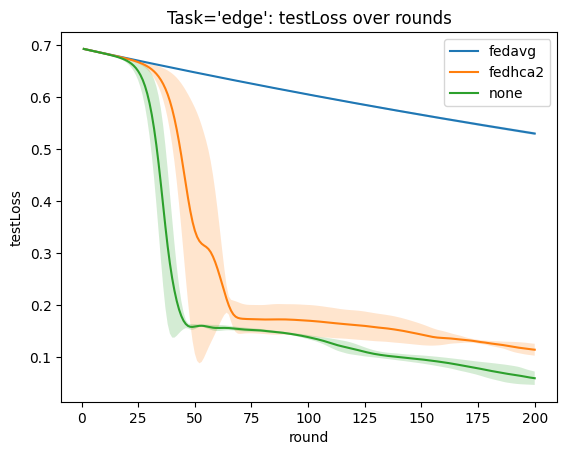

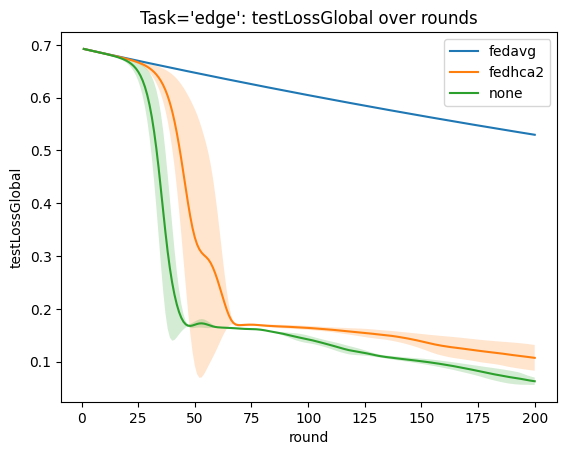

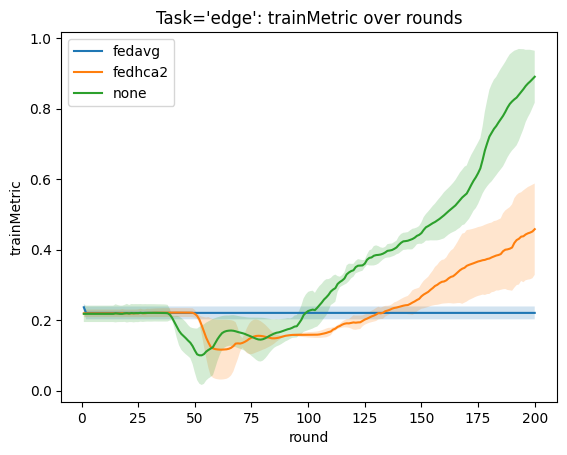

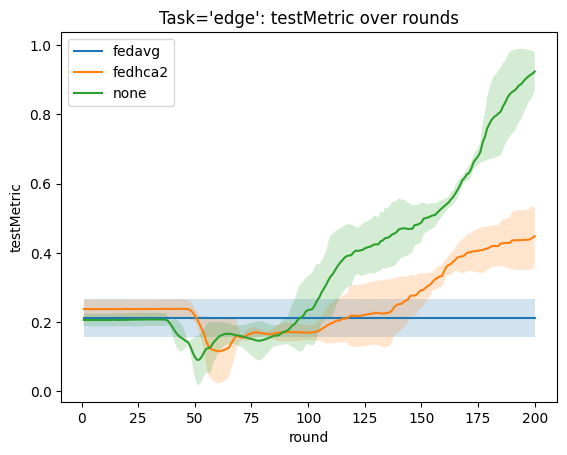

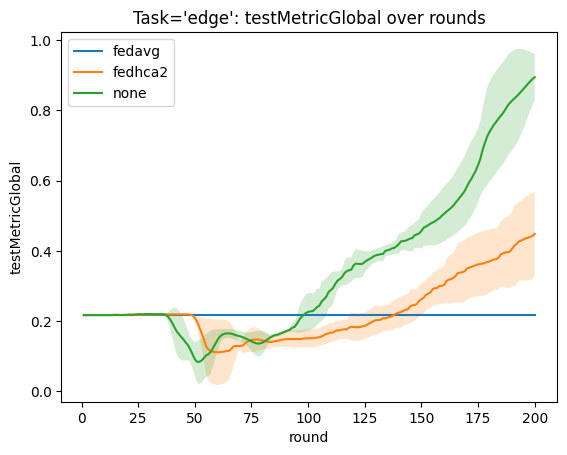

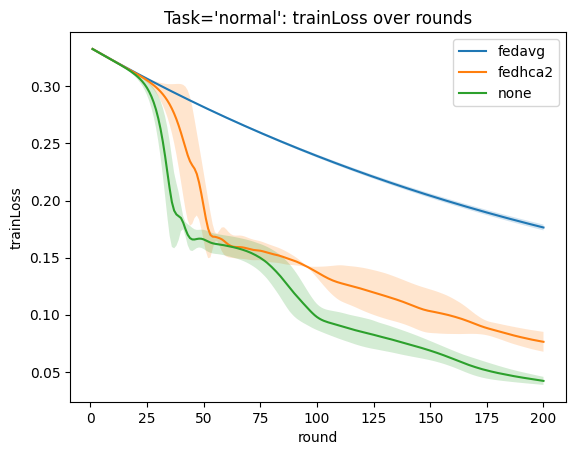

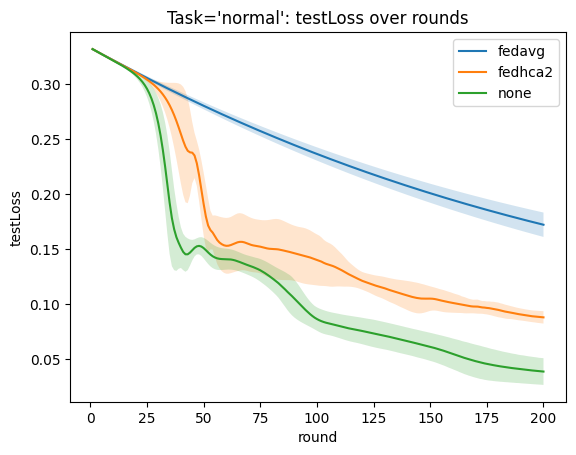

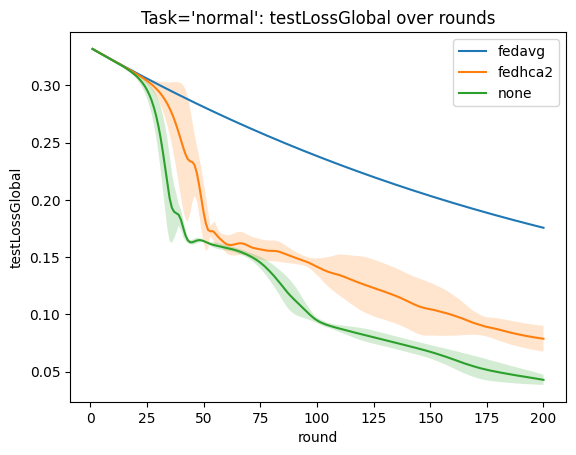

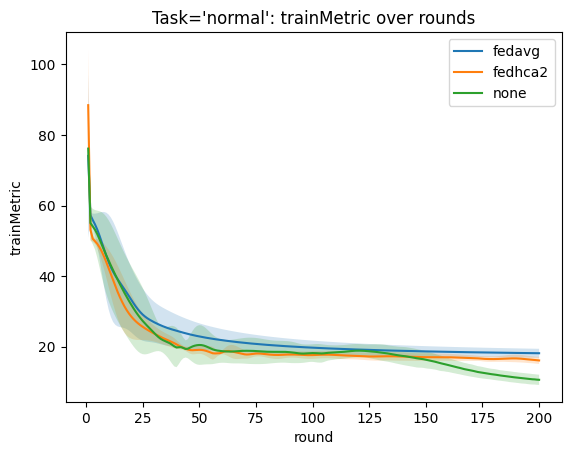

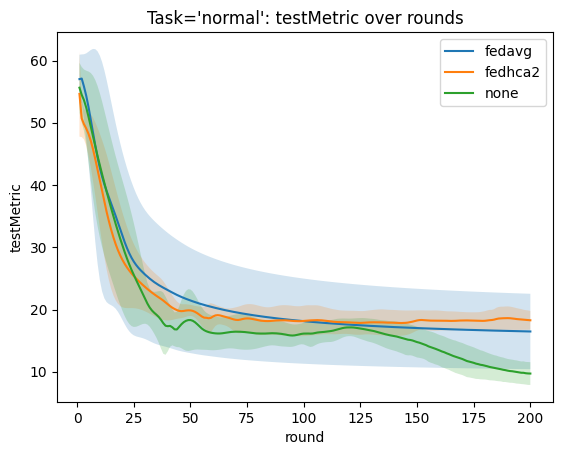

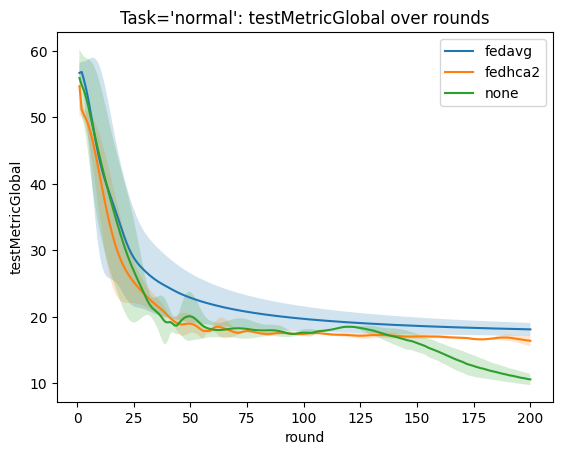

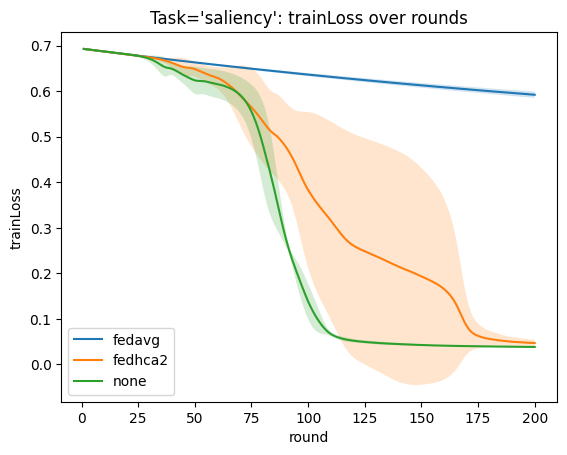

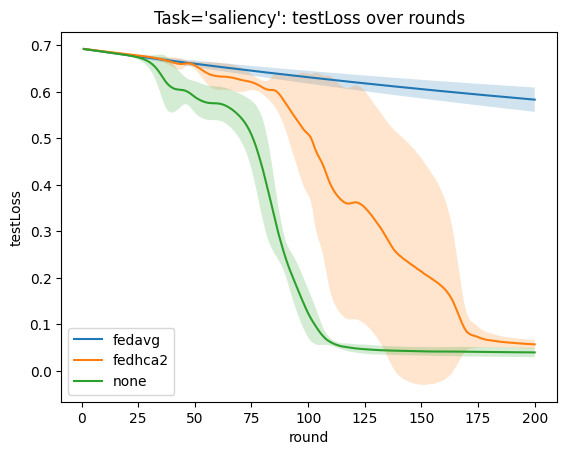

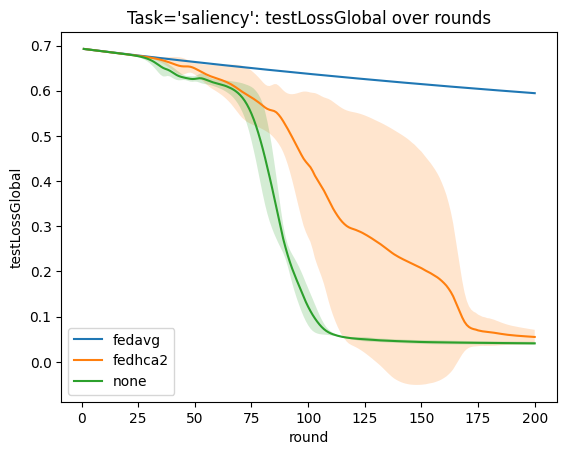

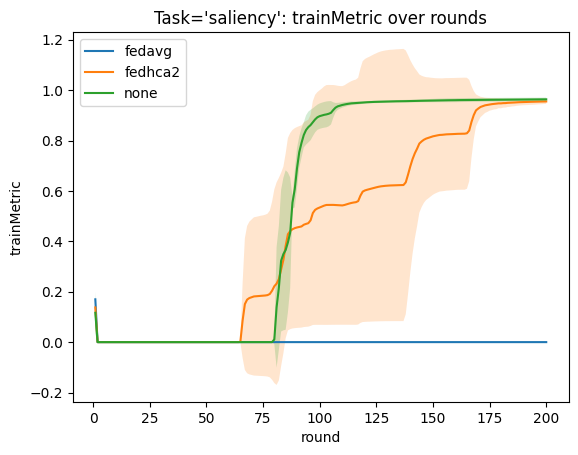

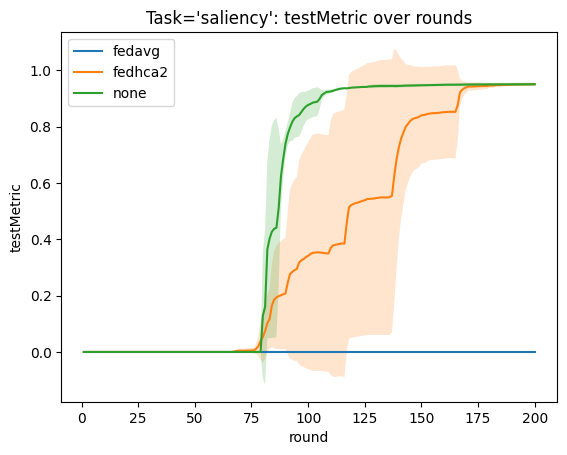

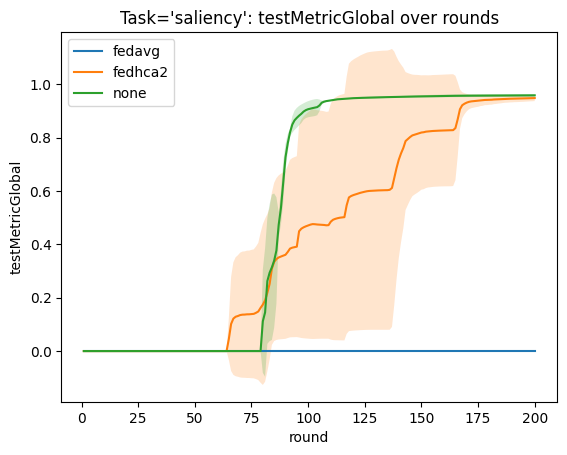

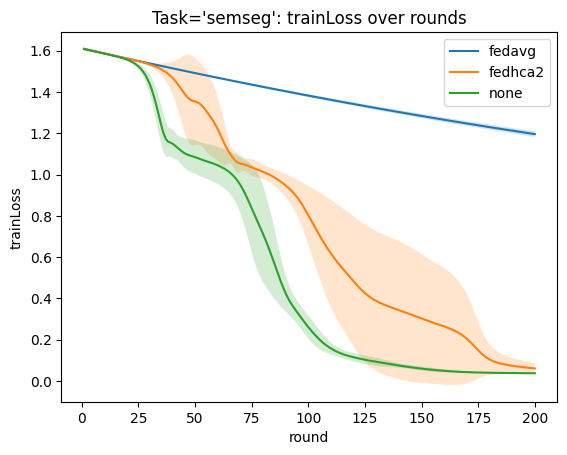

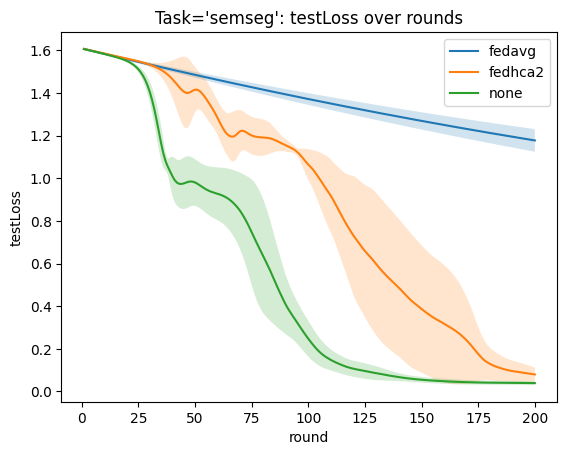

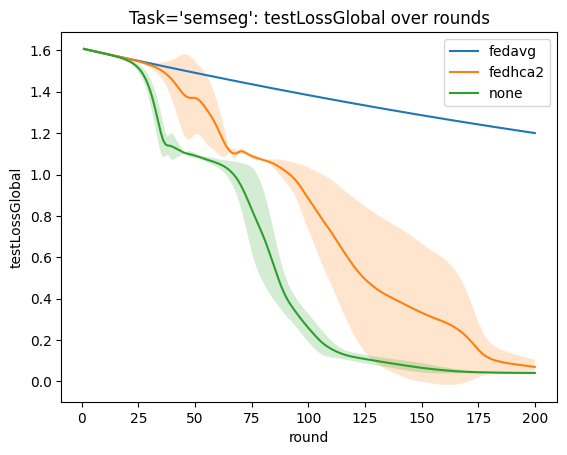

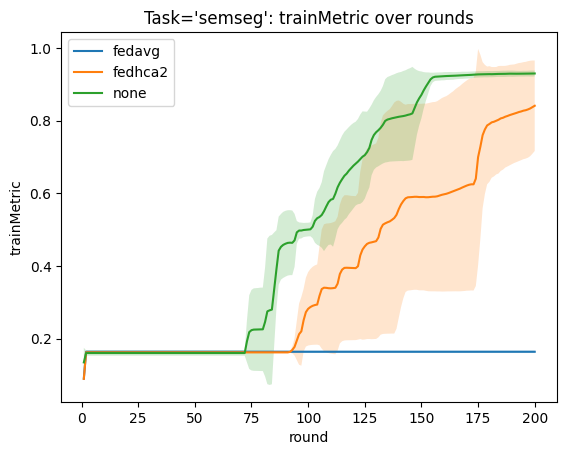

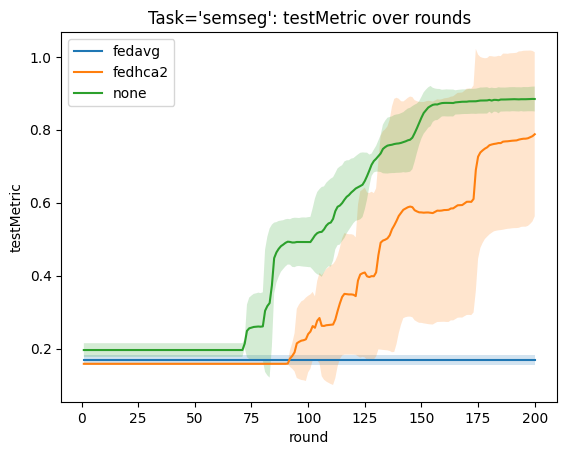

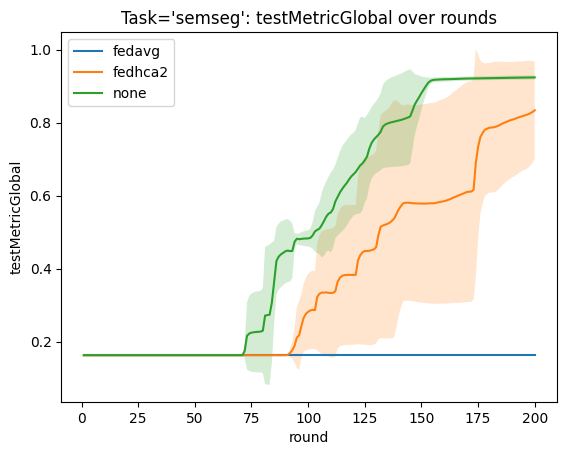

In [8]:
if PLOT_PERTASK:
    tasks = sorted(df_task["task"].dropna().unique().tolist())
    if TASK_WHITELIST is not None:
        tasks = [t for t in tasks if t in TASK_WHITELIST]

    for task in tasks:
        for col in PERTASK_COLUMNS:
            plot_task_metric(task, col)

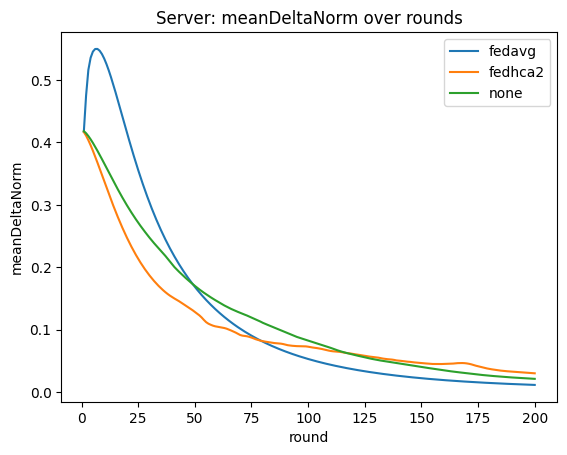

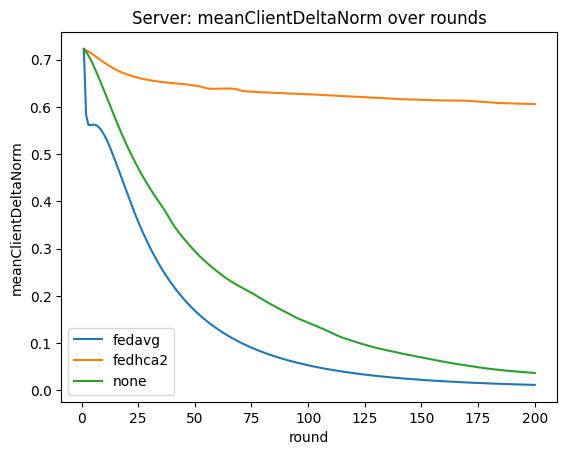

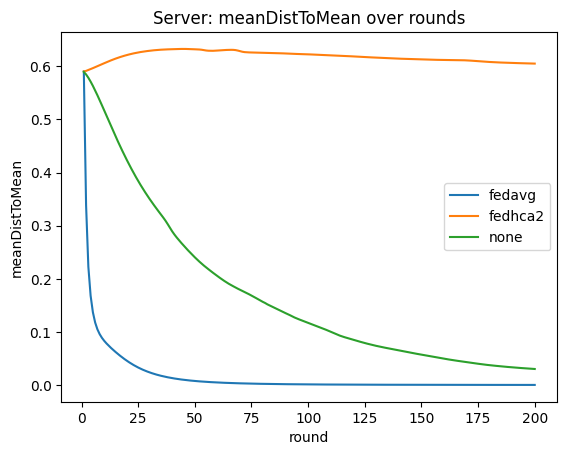

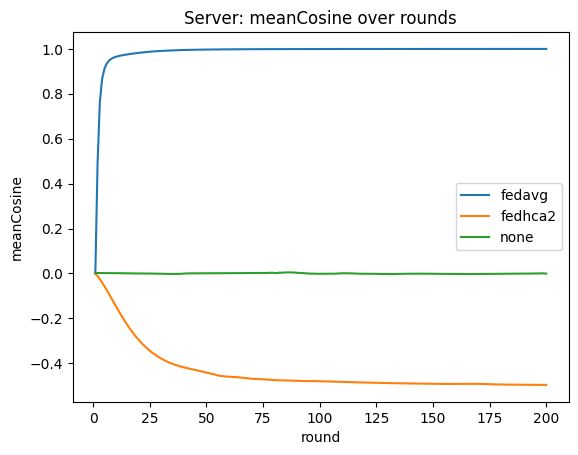

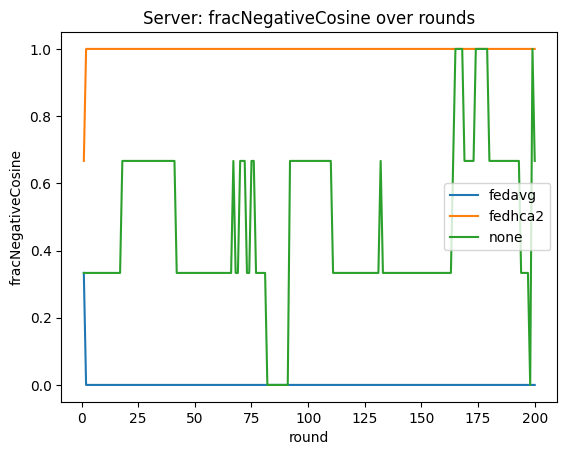

In [10]:
if PLOT_SERVER:
    server_cols = [
        "meanDeltaNorm",
        "meanClientDeltaNorm",
        "meanDistToMean",
        "meanCosine",
        "fracNegativeCosine",
    ]
    for col in server_cols:
        plot_server_metric(col)

In [12]:
# Final-round overall metrics per algo (mean across clients)
final_round = df_client["round"].max()
summary_overall = (
    df_client[df_client["round"] == final_round]
    .groupby("algo")[["lossTrain", "lossTest", "lossTestGlobal"]]
    .agg(["mean", "std"])
)
display(summary_overall)

# Final-round per-task (mean across clients)
final_task = (
    df_task[df_task["round"] == df_task["round"].max()]
    .groupby(["algo", "task"])[PERTASK_COLUMNS]
    .agg(["mean", "std"])
)
display(final_task)

lossTrain            lossTest           lossTestGlobal          
             mean       std      mean       std           mean       std
algo                                                                    
fedavg   2.539550  0.028698  2.499156  0.106950       2.546042  0.001563
fedhca2  0.443102  0.058351  0.351574  0.050182       0.319809  0.085060
none     0.229047  0.019573  0.184799  0.040728       0.196039  0.010177

trainLoss            testLoss           testLossGlobal  \
                      mean       std      mean       std           mean   
algo    task                                                              
fedavg  depth     0.044095  0.005215  0.035978  0.014402       0.045772   
        edge      0.530169  0.000759  0.529469  0.002741       0.529669   
        normal    0.176396  0.002542  0.172421  0.011082       0.175742   
        saliency  0.592325  0.006837  0.583513  0.026168       0.594585   
        semseg    1.196198  0.013830  1.177775  0.053006       1.200274   
fedhca2 depth     0.007774  0.001165  0.012710  0.002841       0.008646   
        edge      0.107112  0.021150  0.113810  0.011487       0.107236   
        normal    0.076268  0.008689  0.088272  0.005653       0.078823   
        saliency  0.046883  0.007297  0.057090  0.009519       0.055049   
        semseg    0.060876  0.025191  0.079692  0.032789       0.070055   
none    depth     0.008147  0.001534  0.007724  0.002818       0.008559   
        edge      0.065494  0.015171  0.058970  0.012890       0.062937   
        normal    0.042028  0.003530  0.039020  0.012147       0.042921   
        saliency  0.038257  0.000874  0.039804  0.010080       0.040928   
        semseg    0.037640  0.000659  0.039282  0.008640       0.040695   

                           trainMetric           testMetric            \
                       std        mean       std       mean       std   
algo    task                                                            
fedavg  depth     0.000048    0.464156  0.012004   0.436362  0.030556   
        edge      0.000031    0.220823  0.018179   0.212824  0.054866   
        normal    0.000182   18.127831  1.260224  16.470707  6.056903   
        saliency  0.000411    0.000000  0.000000   0.000000  0.000000   
        semseg    0.001013    0.163757  0.003473   0.168398  0.014235   
fedhca2 depth     0.000399    0.179237  0.015875   0.226204  0.029029   
        edge      0.024404    0.458205  0.129430   0.448404  0.085793   
        normal    0.011296   16.086144  1.008425  18.271107  1.501925   
        saliency  0.015858    0.955059  0.010034   0.950885  0.003784   
        semseg    0.034556    0.841172  0.124529   0.787642  0.224934   
none    depth     0.000205    0.185143  0.003839   0.197185  0.029139   
        edge      0.006952    0.890331  0.073637   0.923548  0.057020   
        normal    0.004436   10.594098  1.451768   9.711577  1.826679   
        saliency  0.003329    0.963419  0.007143   0.950389  0.005877   
        semseg    0.003718    0.930033  0.008038   0.884259  0.034132   

                 testMetricGlobal            
                             mean       std  
algo    task                                 
fedavg  depth            0.465707  0.006215  
        edge             0.217034  0.000000  
        normal          18.114340  0.966761  
        saliency         0.000000  0.000000  
        semseg           0.162742  0.000000  
fedhca2 depth            0.190825  0.006007  
        edge             0.448360  0.119040  
        normal          16.395259  0.839713  
        saliency         0.948650  0.011372  
        semseg           0.834009  0.133339  
none    depth            0.195492  0.003969  
        edge             0.894908  0.067296  
        normal          10.595051  0.836649  
        saliency         0.958919  0.004755  
        semseg           0.924034  0.005665

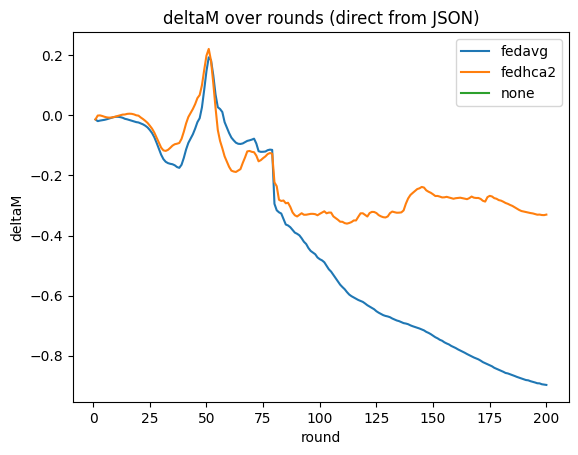

In [16]:
# If deltaM is not present (all None), this will show empty/flat.
plot_algo_scalar(df_delta, "deltaM", "deltaM over rounds (direct from JSON)")

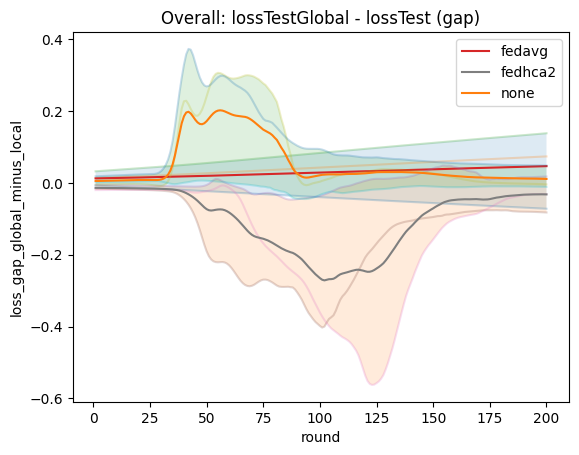

In [17]:
df_gap = df_client.copy()
df_gap["loss_gap_global_minus_local"] = df_gap["lossTestGlobal"] - df_gap["lossTest"]
plot_algo_with_clients(df_gap, "loss_gap_global_minus_local", "Overall: lossTestGlobal - lossTest (gap)")

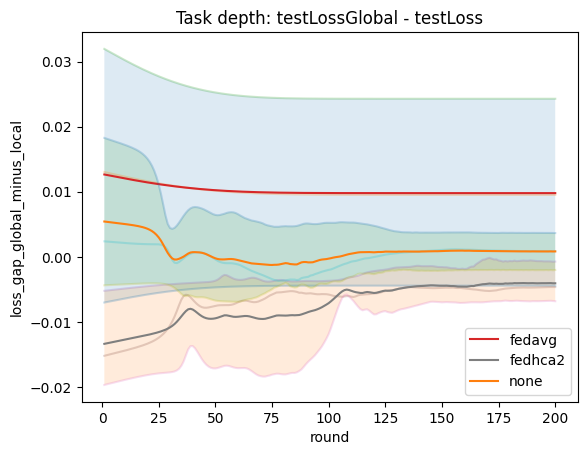

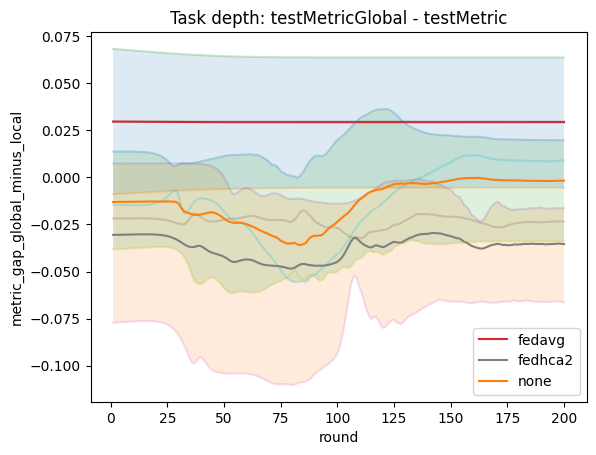

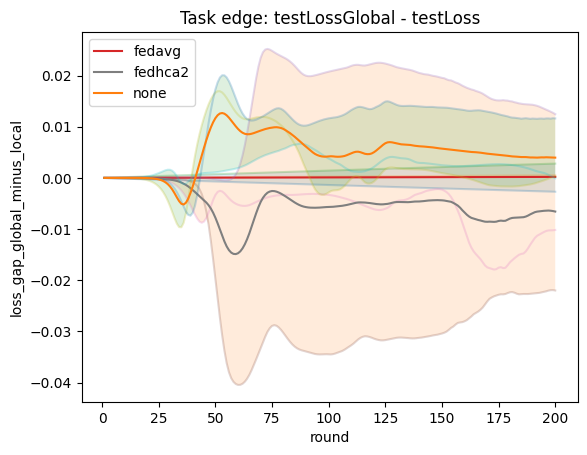

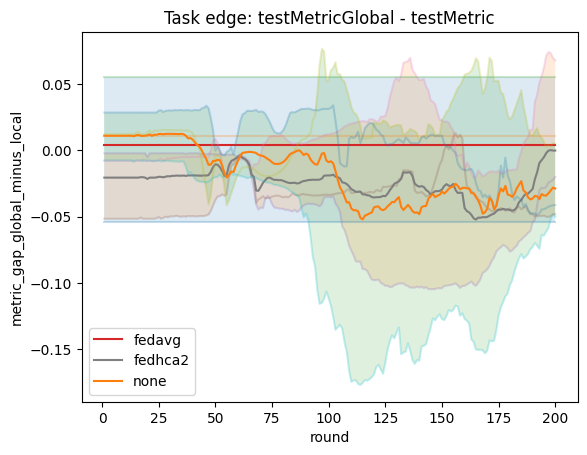

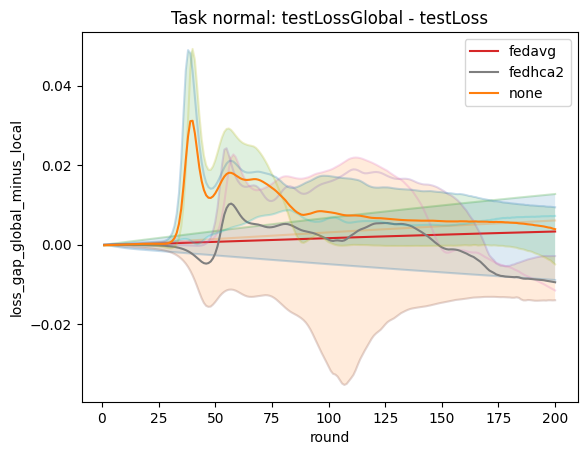

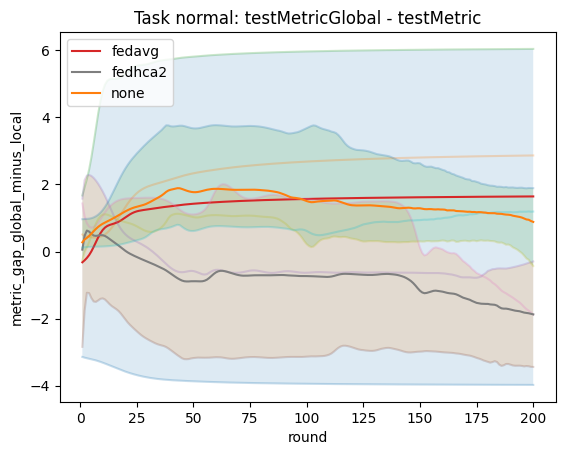

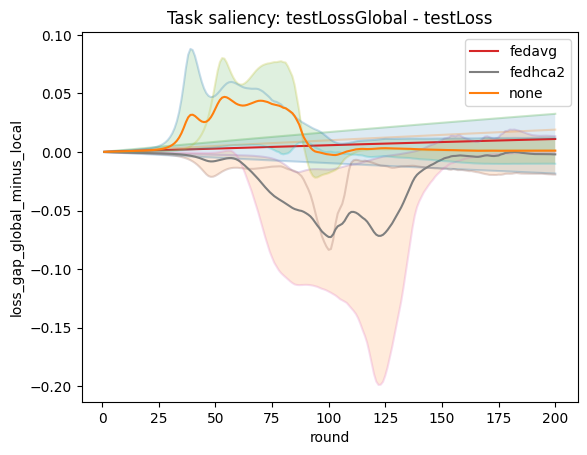

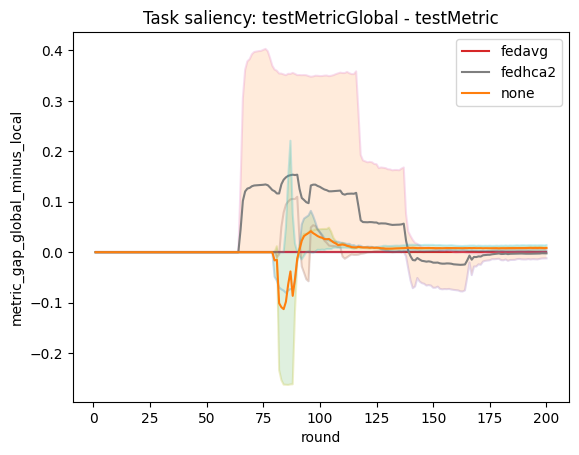

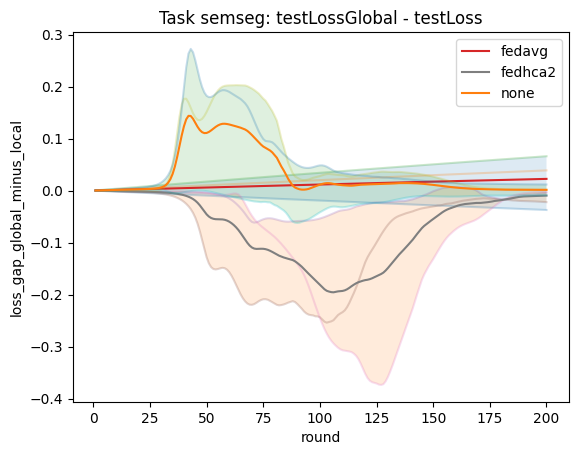

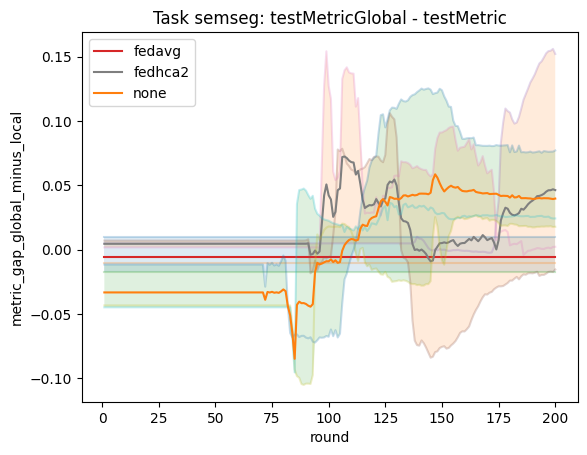

In [18]:
df_tgap = df_task.copy()
df_tgap["loss_gap_global_minus_local"] = df_tgap["testLossGlobal"] - df_tgap["testLoss"]
df_tgap["metric_gap_global_minus_local"] = df_tgap["testMetricGlobal"] - df_tgap["testMetric"]

for task in tasks:
    def _ft(d): return d[d["task"] == task]
    plot_algo_with_clients(df_tgap, "loss_gap_global_minus_local", f"Task {task}: testLossGlobal - testLoss", filter_df=_ft)
    plot_algo_with_clients(df_tgap, "metric_gap_global_minus_local", f"Task {task}: testMetricGlobal - testMetric", filter_df=_ft)